# Пайплайн аугментации

Ноутбук последовательно:
1. Разбивает данные на **train/test** (80/20, стратифицированно)
2. Аугментирует **только train** через 3 этапа
3. Оценивает baseline-классификаторы **на test**

**Этапы аугментации:**
1. LLM-генерация (< 15 → 15)
2. Парафраз через LLM (< 35 → 35)
3. Обратный перевод (< 50 → 50)

**Классификация (baseline):**
- Linear SVM (TF-IDF)
- Logistic Regression (TF-IDF)
- Multinomial Naive Bayes (TF-IDF)
- rubert-tiny2 (fine-tuning)

___
## Подготовка окружения

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import sys
from pathlib import Path
import pandas as pd

# Корень проекта на Google Drive
PROJECT_ROOT = Path("/content/drive/MyDrive/VKR/code/AUG")

# Добавляем корень в sys.path
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

%cd {PROJECT_ROOT}

from src.utils.data_loader import (
    load_dataset, get_class_distribution, split_train_test, load_test_set,
    LABEL_COL, RANDOM_SEED, DATA_DIR, ORIGINAL_FILE,
)

print(f"Корень проекта: {PROJECT_ROOT}")
print(f"Папка данных:   {DATA_DIR}")

/content/drive/MyDrive/VKR/code/AUG
Корень проекта: /content/drive/MyDrive/VKR/code/AUG
Папка данных:   /content/drive/MyDrive/VKR/code/Data


In [3]:
# Ставим зависимости из requirements.txt
!pip install -q -r {PROJECT_ROOT}/requirements.txt

___
## Разделение на train / test

Стратифицированное разбиение 80/20 с гарантией минимум 1 примера на класс в каждой части.
Аугментация применяется **только к train**. Оценка — **на test**.

In [3]:
from src.utils.data_loader import STAGE_FILES, TEST_FILE

train_path = DATA_DIR / STAGE_FILES[0]  # train_after_eda.csv
test_path = DATA_DIR / TEST_FILE         # data_test.csv

if train_path.exists() and test_path.exists():
    # Уже разбито — просто загружаем
    df_train = pd.read_csv(train_path)
    df_test = pd.read_csv(test_path)
    print(f"Train/test уже существуют, загружены из файлов")
else:
    # Первый запуск — разбиваем оригинал
    original_path = DATA_DIR / ORIGINAL_FILE
    df_original = pd.read_csv(original_path)
    print(f"Загружен оригинал: {original_path.name} ({len(df_original)} записей)")
    df_train, df_test = split_train_test(df_original)

print(f"\nTrain: {len(df_train)} ({len(df_train)/(len(df_train)+len(df_test))*100:.0f}%)")
print(f"Test:  {len(df_test)} ({len(df_test)/(len(df_train)+len(df_test))*100:.0f}%)")

Train/test уже существуют, загружены из файлов

Train: 1412 (80%)
Test:  343 (20%)


In [4]:
# Распределение по классам в train и test
dist_train = get_class_distribution(df_train)
dist_test = get_class_distribution(df_test)

print(f"{'Класс':<70} {'Train':>6} {'Test':>5}")
print("-" * 85)
for cls in dist_train.index:
    tr = dist_train[cls]
    te = dist_test.get(cls, 0)
    print(f"  {cls:<68} {tr:>6} {te:>5}")
print("-" * 85)
print(f"  {'ИТОГО':<68} {len(df_train):>6} {len(df_test):>5}")

Класс                                                                   Train  Test
-------------------------------------------------------------------------------------
  Блок технического директора                                             197    49
  Блок директора по мощностям                                             193    48
  Блок директора по строительству                                         132    33
  Управление по проектным работам                                         108    27
  Блок заместителя генерального директора по безопасности                  99    24
  Генеральный директор                                                     82    20
  Проект "Нефтяные краюшки"                                                64    15
  Блок деректора по газу                                                   57    14
  Блок заместителя генерального директора по закупкам                      54    13
  Блок заместителя генерального директора по организационным вопросам     

___
## Baseline — классификация ДО аугментации

Обучаем те же модели на **оригинальном train** (без аугментации), 
чтобы потом сравнить с результатами после аугментации.

In [5]:
from src.classification.evaluate import load_data, evaluate_model
from src.classification.embeddings import prepare_features
from sklearn.preprocessing import LabelEncoder

# Загружаем оригинальный train (stage=0) и test
df_train_orig = load_dataset(stage=0)
df_test_baseline = load_test_set()

X_train_orig, y_train_orig_raw, X_test_orig, y_test_orig_raw = prepare_features(
    df_train_orig, df_test_baseline, use_cache=False
)

le_baseline = LabelEncoder()
y_train_orig = le_baseline.fit_transform(y_train_orig_raw)
y_test_orig = le_baseline.transform(y_test_orig_raw)
label_names_baseline = le_baseline.classes_

print(f"Train (без аугментации): {X_train_orig.shape}")
print(f"Test: {X_test_orig.shape}")
print(f"Классов: {len(label_names_baseline)}")

[Данные] Найден чекпоинт этапа 0: train_after_eda.csv (1412 записей)
[Данные] Тестовая выборка: data_test.csv (343 записей)
[TF-IDF] Параметры: max_features=50000, ngram_range=(1, 2)
[TF-IDF] Обучаю на 1412 текстах...
[TF-IDF] Готово: train (1412, 28793), test (343, 28793)
Train (без аугментации): (1412, 28793)
Test: (343, 28793)
Классов: 36


In [9]:
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

baseline_results = []

print("=" * 60)
print("BASELINE (без аугментации)")
print("=" * 60)

baseline_results.append(evaluate_model(
    name="[Baseline] Linear SVM",
    estimator=LinearSVC(max_iter=10000, random_state=RANDOM_SEED, dual="auto"),
    X_train=X_train_orig, y_train=y_train_orig,
    X_test=X_test_orig, y_test=y_test_orig,
    label_names=label_names_baseline,
    param_grid={"C": [0.01, 0.1, 1, 10]},
))

baseline_results.append(evaluate_model(
    name="[Baseline] Logistic Regression",
    estimator=LogisticRegression(solver="lbfgs", max_iter=1000, random_state=RANDOM_SEED),
    X_train=X_train_orig, y_train=y_train_orig,
    X_test=X_test_orig, y_test=y_test_orig,
    label_names=label_names_baseline,
    param_grid={"C": [0.01, 0.1, 1, 10]},
))

baseline_results.append(evaluate_model(
    name="[Baseline] Multinomial Naive Bayes",
    estimator=MultinomialNB(),
    X_train=X_train_orig, y_train=y_train_orig,
    X_test=X_test_orig, y_test=y_test_orig,
    label_names=label_names_baseline,
    param_grid={"alpha": [0.01, 0.1, 0.5, 1.0]},
))

BASELINE (без аугментации)
КЛАССИФИКАЦИЯ: [Baseline] Linear SVM
[[Baseline] Linear SVM] Train: 1412, Test: 343, Классов: 36


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


[[Baseline] Linear SVM] Лучшие параметры: {'C': 1} (CV macro F1 = 0.4689)

[[Baseline] Linear SVM] Результаты на тестовой выборке:
  Accuracy:    0.6910
  Macro F1:    0.5084
  Weighted F1: 0.6766

                                                                              precision    recall  f1-score   support

                                                       Блок бизнес-директора       0.50      1.00      0.67         1
                                                      Блок деректора по газу       1.00      0.50      0.67        14
                                          Блок директора по газовым проектам       0.80      0.67      0.73         6
                                                 Блок директора по мощностям       0.69      0.92      0.79        48
                                                 Блок директора по персоналу       1.00      0.33      0.50         3
                                                  Блок директора по портфелю       0.50      

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


[[Baseline] Logistic Regression] Лучшие параметры: {'C': 10} (CV macro F1 = 0.3789)

[[Baseline] Logistic Regression] Результаты на тестовой выборке:
  Accuracy:    0.6297
  Macro F1:    0.3668
  Weighted F1: 0.5982

                                                                              precision    recall  f1-score   support

                                                       Блок бизнес-директора       0.00      0.00      0.00         1
                                                      Блок деректора по газу       1.00      0.36      0.53        14
                                          Блок директора по газовым проектам       0.80      0.67      0.73         6
                                                 Блок директора по мощностям       0.65      0.92      0.76        48
                                                 Блок директора по персоналу       0.00      0.00      0.00         3
                                                  Блок директора по портфе

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


[[Baseline] Multinomial Naive Bayes] Лучшие параметры: {'alpha': 0.01} (CV macro F1 = 0.4267)

[[Baseline] Multinomial Naive Bayes] Результаты на тестовой выборке:
  Accuracy:    0.6706
  Macro F1:    0.4667
  Weighted F1: 0.6552

                                                                              precision    recall  f1-score   support

                                                       Блок бизнес-директора       0.00      0.00      0.00         1
                                                      Блок деректора по газу       1.00      0.43      0.60        14
                                          Блок директора по газовым проектам       0.80      0.67      0.73         6
                                                 Блок директора по мощностям       0.74      0.90      0.81        48
                                                 Блок директора по персоналу       1.00      0.33      0.50         3
                                                  Блок дирек

In [10]:
from src.classification.rubert_classifier import train_and_evaluate

baseline_results.append(train_and_evaluate(
    df_train=df_train_orig,
    df_test=df_test_baseline,
    name="[Baseline] rubert-tiny2",
))

[[Baseline] rubert-tiny2] Device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/693 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/401 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

  Epoch 11/15 — loss: 0.0794


  Epoch 12/15 — loss: 0.0602


  Epoch 13/15 — loss: 0.0494


  Epoch 14/15 — loss: 0.0402


  Epoch 15/15 — loss: 0.0362

[[Baseline] rubert-tiny2] Результаты на тестовой выборке:
  Accuracy:    0.5743
  Macro F1:    0.3622
  Weighted F1: 0.5656

                                                                              precision    recall  f1-score   support

                                                       Блок бизнес-директора       0.50      1.00      0.67         1
                                                      Блок деректора по газу       0.67      0.43      0.52        14
                                          Блок директора по газовым проектам       0.50      0.50      0.50         6
                                                 Блок директора по мощностям       0.72      0.71      0.72        48
                                                 Блок директора по персоналу       0.67      0.67      0.67         3
                                                  Блок директора по портфелю       0.00      0.00      0.00         4
                  

___
## Этап 1: LLM-генерация (< 15 -> 15)

Классы с менее чем 15 примерами дополняются новыми текстами,
сгенерированными через LLM.

In [6]:
# Путь до конфига модели 
# CONFIG_PATH = str(PROJECT_ROOT / "configs" / "model_qwen.json")
# урезанная
# CONFIG_PATH = str(PROJECT_ROOT / "configs" / "model_qwen_3b.json")
# квантизированная
CONFIG_PATH = str(PROJECT_ROOT / "configs" / "model_qwen_14b_unsloth.json")
print(f"Конфиг модели: {CONFIG_PATH}")

Конфиг модели: /content/drive/MyDrive/VKR/code/AUG/configs/model_qwen_14b_unsloth.json


In [5]:
from src.augmentation.stage1_llm_generate import run as run_stage1

run_stage1(CONFIG_PATH)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
ЭТАП 1: LLM-генерация (< 15 → 15)
[Данные] Найден чекпоинт этапа 1: data_after_stage1.csv (1493 записей)

[Этап 1] Классов для аугментации: 3
  «Подразделение по информационным технологиям»: 1 → нужно ещё 14
  «Проект «Трубопроводный транспорт Ещё одного НГКМ»»: 1 → нужно ещё 14
  «Блок заместителя генерального директора по строительству»: 1 → нужно ещё 14
[LLM] Загружаю модель: unsloth/Qwen2.5-14B-Instruct-bnb-4bit
==((====))==  Unsloth 2026.3.5: Fast Qwen2 patching. Transformers: 5.2.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red c

Loading weights:   0%|          | 0/579 [00:00<?, ?it/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

unsloth/qwen2.5-14b-instruct-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.
[LLM] Модель загружена, устройство: cuda:0

[Этап 1] Класс «Подразделение по информационным технологиям»: есть 1, нужно ещё 14


--- Logging error ---
Traceback (most recent call last):
  File "/usr/lib/python3.12/logging/__init__.py", line 1160, in emit
    msg = self.format(record)
          ^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/logging/__init__.py", line 999, in format
    return fmt.format(record)
           ^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/logging/__init__.py", line 703, in format
    record.message = record.getMessage()
                     ^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/logging/__init__.py", line 392, in getMessage
    msg = msg % self.args
          ~~~~^~~~~~~~~~~
TypeError: not all arguments converted during string formatting
Call stack:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py", line 37, in <module>
    ColabKernelApp.launch_instance()
  File "/usr/local/lib/python3.12/dist-packages/traitlets/config/application.py", line 992, 

  [Контекст] «Подразделение по информационным технологиям»:
Письма класса "Подразделение по информационным технологиям" содержат официальную информацию о проводимых мероприятиях и услугах компании. Они имеют формальный тон, стандартную структуру с указанием контактной информации, достижениями организации и приглашением на мероприятие или стенды. Обычно используются характерные формулировки типа "приглашаем Вас посетить", сопровождающиеся ссылками на конкретные продукты и услуги. Отправителями выступают коммерческие или технические руководители, а адресатами - главные метрологи и ведущие специалисты соответствующих областей.

  [Генерация] Нужно ещё 14, попыток: 1/140
[Валидация] Класс «Подразделение по информационным технологиям»: проверяем 1 сгенерированных текстов
[Валидация] Загружаю SBERT-модель: ai-forever/sbert_large_nlu_ru


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

[Валидация] SBERT-модель загружена (CPU)
[Валидация] Класс «Подразделение по информационным технологиям»: прошло 1/1, отсеяно 0
[Валидация] Класс «Подразделение по информационным технологиям»: проверяем 1 сгенерированных текстов
[Валидация] Класс «Подразделение по информационным технологиям»: прошло 1/1, отсеяно 0
[Валидация] Класс «Подразделение по информационным технологиям»: проверяем 1 сгенерированных текстов
[Валидация] Класс «Подразделение по информационным технологиям»: прошло 1/1, отсеяно 0
[Валидация] Класс «Подразделение по информационным технологиям»: проверяем 1 сгенерированных текстов
[Валидация] Класс «Подразделение по информационным технологиям»: прошло 1/1, отсеяно 0
[Валидация] Класс «Подразделение по информационным технологиям»: проверяем 1 сгенерированных текстов
[Валидация] Класс «Подразделение по информационным технологиям»: прошло 1/1, отсеяно 0
  [Генерация] Нужно ещё 9, попыток: 6/140
[Валидация] Класс «Подразделение по информационным технологиям»: проверяем 1 с

In [6]:
df_after_s1 = load_dataset(stage=1)
dist_s1 = get_class_distribution(df_after_s1)
while (dist_s1 < 15).sum() != 0:# Проверяем результат после этапа 1
    print(f"Записей после этапа 1: {len(df_after_s1)}")
    print(f"Классов с < 15 примерами: {(dist_s1 < 15).sum()}")
    print(f"{"="*100}\n\n")
    print("Повторяем 1й этап")
    print(f"\n\n{"="*100}")
    run_stage1(CONFIG_PATH)
    df_after_s1 = load_dataset(stage=1)
    dist_s1 = get_class_distribution(df_after_s1)
print("Этап 1: Генерация с помощью LLM полностью завершен.")

[Данные] Найден чекпоинт этапа 1: data_after_stage1.csv (1535 записей)
Этап 1: Генерация с помощью LLM полностью завершен.


## 3. Этап 2: Парафраз через LLM (< 35 -> 35)

Классы с менее чем 35 примерами пополняются через перефразирование
существующих текстов — LLM получает оригинал и переписывает его
другими словами, сохраняя смысл.

In [1]:
import torch, gc
gc.collect()
torch.cuda.empty_cache()
print(f"VRAM свободно: {torch.cuda.mem_get_info()[0] / 1e9:.1f} ГБ")


VRAM свободно: 3.5 ГБ


In [6]:
from src.augmentation.stage2_paraphrase import run as run_stage2

run_stage2(CONFIG_PATH)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
ЭТАП 2: Парафраз через LLM (< 35 → 35)
[Данные] Найден чекпоинт этапа 2: data_after_stage2.csv (1895 записей)

[Этап 2] Классов для аугментации: 13
  «Блок заместителя генерального директора по строительству»: 15 → нужно ещё 20
  «Проект «Обустройство объектов Новейшей нейти»»: 26 → нужно ещё 9
  «Проект «Трубопроводный транспорт Ещё одного НГКМ»»: 31 → нужно ещё 4
  «Блок бизнес-директора»: 32 → нужно ещё 3
  «Проект "Восточный"»: 33 → нужно ещё 2
  «Подразделение по информационным технологиям»: 33 → нужно ещё 2
  «Проект "Южный"»: 34 → нужно ещё 1
  «Проект "Трубопроводный транспорт Главного НГКМ"»: 34 → нужно ещё 1
  «Блок директора по персоналу»: 34 → нужно ещё 1
  «Блок директора по газовым проектам»: 34 → нужно ещё 1
  «Проект «Обустройство объектов Новой нефти»»: 34 → нужно ещё 1
  «Имущественные вопросы»: 34 → нужно ещё 1
  «Управление землеу

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/579 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

[Валидация] SBERT-модель загружена (CPU)
[Валидация] Класс «Проект "Южный"»: прошло 1/1, отсеяно 0
[Этап 2] Класс «Проект "Южный"»: добавлено 1 парафразов
Пример сгенерированного письма:
--------------------------------------------------
Филиал "Обслуживание Ямбургского НГКМ" ООО "[ORGANIZATION] ИНВЕСТ"

Дорогой Петр Петрович,

Дорогой Сергей Сергеевич,

Продолжая работу над проектом "Южный" (идентификационный номер - [DOCUMENT_NUMBER]), наш отдел проектирования отправляет вам письмо от [DATE_TIME], которое имеет номер [DOCUMENT_NUMBER]. В нем затрагивается вопрос о возможности прокладки трассы между Песцовским и Ямбургским месторождениями.

Просим вас поручить специалистам рассмотреть предложение проектировщиков относительно маршрута подхода к блоку под номером [DOCUMENT_NUMBER] и предоставить свои выводы и рекомендации.

Вложения включают:
1. Сообщение от службы проектирования, датированное [DATE_TIME], с номером [DOCUMENT_NUMBER],
2. Топографическую карту района (лист).

Ваш временн

In [7]:
# Проверяем результат после этапа 2
df_after_s2 = load_dataset(stage=2)
dist_s2 = get_class_distribution(df_after_s2)

print(f"Записей после этапа 2: {len(df_after_s2)}")
print(f"Классов с < 35 примерами: {(dist_s2 < 35).sum()}")

[Данные] Найден чекпоинт этапа 2: data_after_stage2.csv (1932 записей)
Записей после этапа 2: 1932
Классов с < 35 примерами: 5


## 4. Этап 3: Обратный перевод (< 50 -> 50)

Оставшиеся классы с менее чем 50 примерами дополняются через
обратный перевод RU → EN → RU (facebook/nllb-200-distilled-600M).

In [7]:
from src.augmentation.stage3_back_translation import run as run_stage3

run_stage3()

ЭТАП 3: Обратный перевод (< 50 → 50)
[Данные] Чекпоинт этапа 3 не найден, загружен этап 2: data_after_stage2.csv (1932 записей)

[Этап 3] Классов для аугментации: 27
  «Проект «Обустройство объектов Новейшей нейти»»: 30 → нужно ещё 20
  «Блок заместителя генерального директора по строительству»: 33 → нужно ещё 17
  «Подразделение по информационным технологиям»: 34 → нужно ещё 16
  «Блок бизнес-директора»: 34 → нужно ещё 16
  «Имущественные вопросы»: 34 → нужно ещё 16
  «Блок директора по проектированию»: 35 → нужно ещё 15
  «Блок финансового директора»: 35 → нужно ещё 15
  «Проект «Обустройство объектов Новой нефти»»: 35 → нужно ещё 15
  «Блок директора по персоналу»: 35 → нужно ещё 15
  «Проект "Трубопроводный транспорт Главного НГКМ"»: 35 → нужно ещё 15
  «Блок директора по газовым проектам»: 35 → нужно ещё 15
  «Блок операционного директора»: 35 → нужно ещё 15
  «Проект "Южный"»: 35 → нужно ещё 15
  «Блок директора по портфелю»: 35 → нужно ещё 15
  «Проект "Восточный"»: 35 → нужно е

Loading weights:   0%|          | 0/1016 [00:00<?, ?it/s]

OutOfMemoryError: CUDA out of memory. Tried to allocate 64.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 53.81 MiB is free. Including non-PyTorch memory, this process has 14.51 GiB memory in use. Of the allocated memory 14.40 GiB is allocated by PyTorch, and 10.95 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
# Проверяем финальный результат
df_final = load_dataset(stage=3)
dist_final = get_class_distribution(df_final)

print(f"Записей после всех этапов: {len(df_final)}")
print(f"Классов с < 50 примерами: {(dist_final < 50).sum()}")
print(f"\nМинимум примеров в классе: {dist_final.min()}")
print(f"Максимум примеров в классе: {dist_final.max()}")

[Данные] Найден чекпоинт этапа 3: data_after_stage3.csv (2143 записей)
Записей после всех этапов: 2143
Классов с < 50 примерами: 25

Минимум примеров в классе: 37
Максимум примеров в классе: 197


In [ ]:
import matplotlib.pyplot as plt

# Сравниваем распределение: train до и после аугментации
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

dist_train.plot(kind="bar", ax=axes[0], color="salmon")
axes[0].set_title("Train до аугментации")
axes[0].set_ylabel("Количество примеров")
axes[0].tick_params(axis="x", rotation=45)

dist_final.plot(kind="bar", ax=axes[1], color="steelblue")
axes[1].set_title("Train после аугментации")
axes[1].set_ylabel("Количество примеров")
axes[1].axhline(y=50, color="g", linestyle="--", alpha=0.5, label="Целевой минимум (50)")
axes[1].legend()
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

___
## Классификация — оценка качества аугментации

Обучаем на аугментированном train, оцениваем на отложенном test.
Данные загружаются один раз, все модели используют одни и те же эмбеддинги.

### Загрузка данных и эмбеддингов

In [ ]:
from src.classification.evaluate import load_data, evaluate_model

X_train, y_train, X_test, y_test, label_names = load_data()

print(f"Train: {X_train.shape}, Test: {X_test.shape}, Классов: {len(label_names)}")

[Данные] Найден чекпоинт этапа 3: data_after_stage3.csv (2143 записей)
[Данные] Тестовая выборка: data_test.csv (343 записей)
[TF-IDF] Параметры: max_features=50000, ngram_range=(1, 2)
[TF-IDF] Обучаю на 2143 текстах...
[TF-IDF] Готово: train (2143, 39089), test (343, 39089)
[TF-IDF] Кэш сохранён (ключ: 52da9f985954)
Train: (2143, 39089), Test: (343, 39089), Классов: 36


### Linear SVM

In [ ]:
from sklearn.svm import LinearSVC

augmented_results = []

augmented_results.append(evaluate_model(
    name="[Augmented] Linear SVM",
    estimator=LinearSVC(max_iter=10000, random_state=RANDOM_SEED, dual="auto"),
    X_train=X_train, y_train=y_train,
    X_test=X_test, y_test=y_test,
    label_names=label_names,
    param_grid={"C": [0.01, 0.1, 1, 10]},
))

КЛАССИФИКАЦИЯ: [Augmented] Linear SVM
[[Augmented] Linear SVM] Train: 2143, Test: 343, Классов: 36
[[Augmented] Linear SVM] Лучшие параметры: {'C': 10} (CV macro F1 = 0.7841)

[[Augmented] Linear SVM] Результаты на тестовой выборке:
  Accuracy:    0.6793
  Macro F1:    0.5008
  Weighted F1: 0.6705

                                                                              precision    recall  f1-score   support

                                                       Блок бизнес-директора       0.50      1.00      0.67         1
                                                      Блок деректора по газу       0.89      0.57      0.70        14
                                          Блок директора по газовым проектам       0.57      0.67      0.62         6
                                                 Блок директора по мощностям       0.71      0.92      0.80        48
                                                 Блок директора по персоналу       1.00      0.33      0.50  

### Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

augmented_results.append(evaluate_model(
    name="[Augmented] Logistic Regression",
    estimator=LogisticRegression(solver="lbfgs", max_iter=1000, random_state=RANDOM_SEED),
    X_train=X_train, y_train=y_train,
    X_test=X_test, y_test=y_test,
    label_names=label_names,
    param_grid={"C": [0.01, 0.1, 1, 10]},
))

КЛАССИФИКАЦИЯ: [Augmented] Logistic Regression
[[Augmented] Logistic Regression] Train: 2143, Test: 343, Классов: 36
[[Augmented] Logistic Regression] Лучшие параметры: {'C': 10} (CV macro F1 = 0.7356)

[[Augmented] Logistic Regression] Результаты на тестовой выборке:
  Accuracy:    0.6443
  Macro F1:    0.4286
  Weighted F1: 0.6207

                                                                              precision    recall  f1-score   support

                                                       Блок бизнес-директора       0.00      0.00      0.00         1
                                                      Блок деректора по газу       1.00      0.36      0.53        14
                                          Блок директора по газовым проектам       0.80      0.67      0.73         6
                                                 Блок директора по мощностям       0.67      0.92      0.77        48
                                                 Блок директора по персон

### Multinomial Naive Bayes

In [ ]:
from sklearn.naive_bayes import MultinomialNB

augmented_results.append(evaluate_model(
    name="[Augmented] Multinomial Naive Bayes",
    estimator=MultinomialNB(),
    X_train=X_train, y_train=y_train,
    X_test=X_test, y_test=y_test,
    label_names=label_names,
    param_grid={"alpha": [0.01, 0.1, 0.5, 1.0]},
))

КЛАССИФИКАЦИЯ: [Augmented] Multinomial Naive Bayes
[[Augmented] Multinomial Naive Bayes] Train: 2143, Test: 343, Классов: 36
[[Augmented] Multinomial Naive Bayes] Лучшие параметры: {'alpha': 0.01} (CV macro F1 = 0.7754)

[[Augmented] Multinomial Naive Bayes] Результаты на тестовой выборке:
  Accuracy:    0.6647
  Macro F1:    0.4579
  Weighted F1: 0.6462

                                                                              precision    recall  f1-score   support

                                                       Блок бизнес-директора       0.00      0.00      0.00         1
                                                      Блок деректора по газу       0.86      0.43      0.57        14
                                          Блок директора по газовым проектам       0.75      0.50      0.60         6
                                                 Блок директора по мощностям       0.70      0.92      0.79        48
                                                 Бл

### rubert-tiny2 (fine-tuning)

In [ ]:
from src.classification.rubert_classifier import train_and_evaluate

# df_final уже загружен выше (stage=3), df_test_baseline тоже
augmented_results.append(train_and_evaluate(
    df_train=df_final,
    df_test=df_test_baseline,
    name="[Augmented] rubert-tiny2",
))

[[Augmented] rubert-tiny2] Device: cuda


Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider trai

[[Augmented] rubert-tiny2] Train: 2143, Test: 343, Классов: 36, Эпох: 15


  Epoch 1/15 — loss: 3.3056


...

  Epoch 11/15 — loss: 0.0081


  Epoch 12/15 — loss: 0.0078


  Epoch 13/15 — loss: 0.0066


  Epoch 14/15 — loss: 0.0062


  Epoch 15/15 — loss: 0.0062

[[Augmented] rubert-tiny2] Результаты на тестовой выборке:
  Accuracy:    0.5977
  Macro F1:    0.4389
  Weighted F1: 0.5952

                                                                              precision    recall  f1-score   support

                                                       Блок бизнес-директора       0.25      1.00      0.40         1
                                                      Блок деректора по газу       0.70      0.50      0.58        14
                                          Блок директора по газовым проектам       0.50      0.67      0.57         6
                                                 Блок директора по мощностям       0.72      0.65      0.68        48
                                                 Блок директора по персоналу       0.67      0.67      0.67         3
                                                  Блок директора по портфелю       0.20      0.25      0.22         4
                 

___
## Сравнение: Baseline vs Augmented

Сводная таблица и график — как изменились метрики после аугментации для каждого классификатора.

Модель                    | Метрика      |   Baseline |  Augmented |      Delta
---------------------------------------------------------------------------
  Linear SVM              | Accuracy     |     0.6910 |     0.6793 |   -0.0117
  Linear SVM              | Macro F1     |     0.5084 |     0.5008 |   -0.0077
  Linear SVM              | Weighted F1  |     0.6766 |     0.6705 |   -0.0061
---------------------------------------------------------------------------
  Logistic Regression     | Accuracy     |     0.6297 |     0.6443 | +   0.0146
  Logistic Regression     | Macro F1     |     0.3668 |     0.4286 | +   0.0618
  Logistic Regression     | Weighted F1  |     0.5982 |     0.6207 | +   0.0225
---------------------------------------------------------------------------
  Multinomial Naive Bayes | Accuracy     |     0.6706 |     0.6647 |   -0.0058
  Multinomial Naive Bayes | Macro F1     |     0.4667 |     0.4579 |   -0.0087
  Multinomial Naive Bayes | Weighted F1  |     0.6552 |  

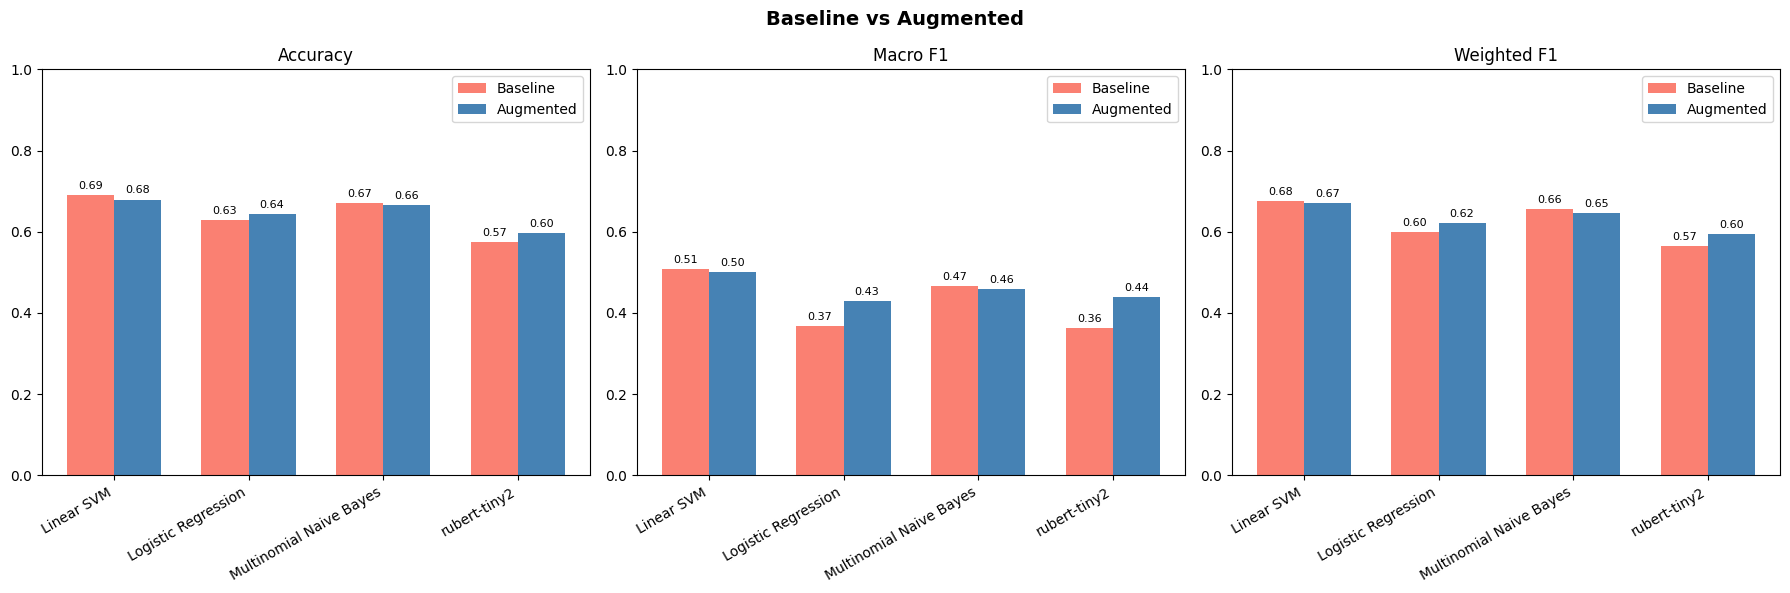

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Построим словари name -> result
base_dict = {r["name"].split("] ")[1]: r for r in baseline_results}
aug_dict  = {r["name"].split("] ")[1]: r for r in augmented_results}

# Общие модели (сохраняя порядок baseline)
model_names = [n for n in base_dict if n in aug_dict]

metrics = ["accuracy", "macro_f1", "weighted_f1"]
metric_labels = ["Accuracy", "Macro F1", "Weighted F1"]

# Таблица
print(f"{'Модель':<25} | {'Метрика':<12} | {'Baseline':>10} | {'Augmented':>10} | {'Delta':>10}")
print("-" * 75)
for name in model_names:
    for m, ml in zip(metrics, metric_labels):
        b = base_dict[name][m]
        a = aug_dict[name][m]
        delta = a - b
        sign = "+" if delta >= 0 else ""
        print(f"  {name:<23} | {ml:<12} | {b:>10.4f} | {a:>10.4f} | {sign}{delta:>9.4f}")
    print("-" * 75)

# График
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

x = np.arange(len(model_names))
width = 0.35

for ax, m, ml in zip(axes, metrics, metric_labels):
    vals_b = [base_dict[n][m] for n in model_names]
    vals_a = [aug_dict[n][m]  for n in model_names]


    bars_b = ax.bar(x - width/2, vals_b, width, label="Baseline", color="salmon")
    bars_a = ax.bar(x + width/2, vals_a, width, label="Augmented", color="steelblue")

    ax.set_title(ml)
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=30, ha="right")
    ax.set_ylim(0, 1)
    ax.legend()

    # Подписи значений
    for bar in bars_b:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=8)
    for bar in bars_a:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=8)

plt.suptitle("Baseline vs Augmented", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()